The Dose and NetOD data comes from my Matlab Filmcalibration script. I imported it here:

In [66]:
#Preamble
import pandas as pd
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

#Read in data
data = pd.read_excel("../Calibration data_finalfornow/Dose and OD data.xlsx")
Doses = data["Dose"].to_numpy()
netOD = data["Avg netOD"].to_numpy()

In [ ]:
'''
#Load function information that Matlab script stored
function_info = sio.loadmat("../Calibration data_finalfornow/Calibration_data.mat")
#The fitted parameters a and b
x = function_info["x"]
#The n
n = function_info["n"]
'''

(0.0, 0.5401274887340468)

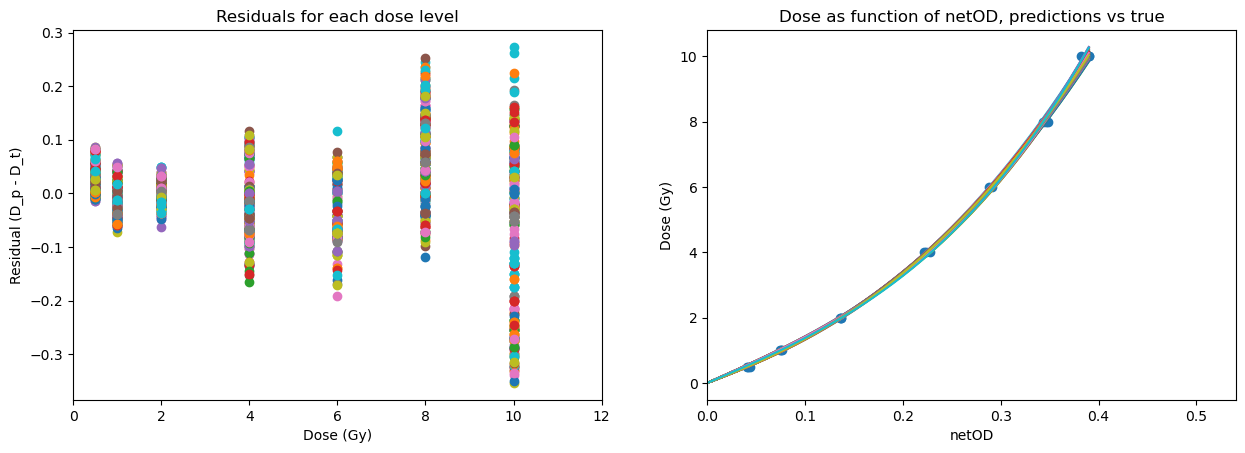

In [67]:
#Sample size
n_sample = len(Doses)
#number of bootstrap samples
n_bootstraps = 100

#Values for parameter n
n_values = np.arange(0, 5.5, 0.5)

Residuals = np.zeros([n_bootstraps, n_sample])

#prepare figures
figure, axis = plt.subplots(1,2)
axis[1].scatter(netOD, Doses, label="True")
figure.set_figwidth(15)

for bs in range(n_bootstraps):
    #Resample the data into a bootstrap sample (so with replacement)
    indices = np.random.randint(0,n_sample, n_sample) #randomly generate indexes
    #resample data
    Doses_b = Doses[indices]
    netOD_b = netOD[indices]
    #Sort data in ascending order
    index = np.argsort(Doses_b)
    Doses_b = np.array([Doses_b[i] for i in index])
    netOD_b = np.array([netOD_b[i] for i in index])

    #refit parameters
    R2scores = []
    for n in n_values:
        #Definition of function we're fitting
        def func(OD, a, b):
            return a*OD + b*np.power(OD,n)
        
        #Fit curve
        params, pcov = curve_fit(func, netOD_b, Doses_b)

        #Find R2 score
        R2 = r2_score(Doses_b,func(netOD_b, params[0], params[1]))
        R2scores.append(R2)

    #Find best n
    n_best = n_values[np.argmax(R2scores)]

    #Refit with this n
    def func_final(OD, a, b):
        return a*OD + b*np.power(OD,n_best)
        
    #Fit curve
    params, pcov = curve_fit(func_final, netOD_b, Doses_b)

    #predict with these parameters
    Doses_b_prediction = func_final(netOD_b, params[0], params[1])

    #Find residuals from prediction
    Residuals[bs,:] = Doses_b_prediction - Doses_b

    #Plot residuals for each dose level
    axis[0].scatter(Doses_b, Residuals[bs,:], label=str(bs))

    #Plot prediction vs data for each dose level
    axis[1].plot(np.arange(0, np.max(netOD), 0.01), func_final(np.arange(0, np.max(netOD), 0.01), params[0], params[1]), label=str(bs))

#Customise residual plot
axis[0].set_xlabel("Dose (Gy)")
axis[0].set_ylabel("Residual (D_p - D_t)")
axis[0].set_title("Residuals for each dose level")
axis[0].set_xlim([0, 12])
#axis[0].legend(loc="center right")

#Customise prediction plot
axis[1].set_xlabel("netOD")
axis[1].set_ylabel("Dose (Gy)")
axis[1].set_title("Dose as function of netOD, predictions vs true")
axis[1].set_xlim([0, max(netOD)+0.15])
#axis[1].legend(loc="center right")

Text(0, 0.5, 'Count')

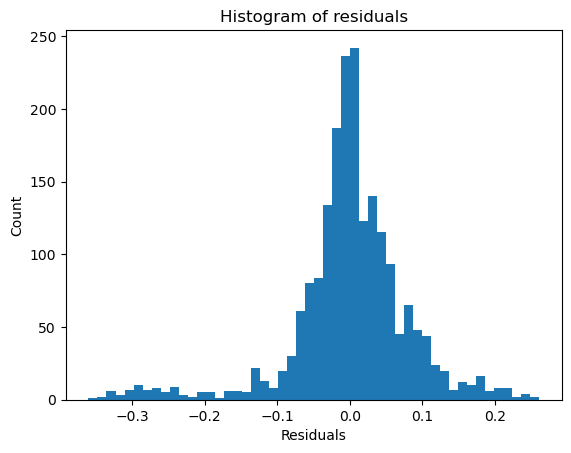

In [65]:
#Make residuals data into a 1D array, sorted smallest to largest
Res = Residuals.reshape(-1)
index = np.argsort(Res)
Res = np.array([Res[i] for i in index])

plt.title("Histogram of residuals");
plt.hist(Res, bins=50)
plt.xlabel("Residuals")
plt.ylabel("Count")

In [53]:
#Iteratively loop through uncertainty values until 95% of residual data lies within these values
uncertainty_values = np.arange(0.01, 1, 0.01)

for u in uncertainty_values:
    #Find residual values within the range -u to u
    locs = np.where((Res > -u) & (Res < u))

    #Divide by total number of residuals to find percentage
    percentage = len(locs[0])/len(Res)

    #Once 95 percent is reached, break out of loop
    if percentage > 0.95:
        break

#Print data
print("Uncertainty value: \u00B1" + str(round(u,2)))
print("Percentage of data within these bounds: " + str(percentage*100) + "%")


Uncertainty value: ±0.2
Percentage of data within these bounds: 95.45%


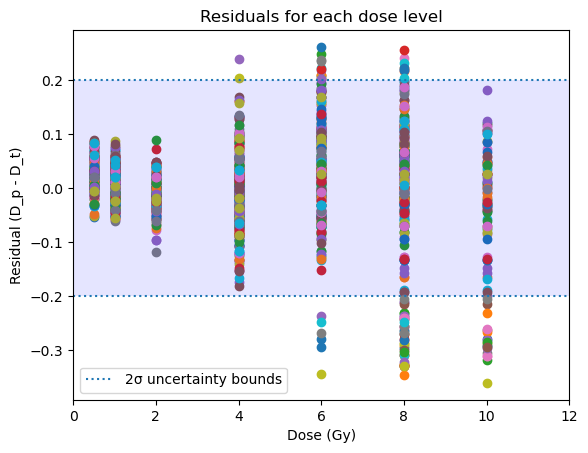

In [63]:
#Replot residuals with this data
for bs in range(np.size(Residuals,0)):
    plt.scatter(Doses_b, Residuals[bs,:])

plt.xlabel("Dose (Gy)")
plt.ylabel("Residual (D_p - D_t)")
plt.title("Residuals for each dose level")
plt.xlim([0, 12])
plt.axhline(u, linestyle=":", label="2\u03C3 uncertainty bounds")
plt.axhline(-u, linestyle=":")
plt.axhspan(-u, u, facecolor='blue', alpha=0.1)
plt.legend()